# Build 00 — Data Exploration & EDA Template

> *Allianz Insurance Claims Dataset EDA Pipeline — hands-on with what we actually have*

**EN:** This notebook does two things in sequence: (1) defines the reusable EDA functions intended for the real Allianz dataset (`CONFIG`-driven, schema-flexible), then (2) walks you through the public insurance datasets in `datasets/real/` so you can **eyeball them**, **see how their schema differs from `CONFIG`**, **apply a mapping**, and **run the full EDA** end-to-end before the real data arrives.

**KR:** 이 노트북은 두 가지를 순서대로 합니다. (1) 실 Allianz 데이터셋용 EDA 함수들을 정의(`CONFIG` 기반 스키마 유연), (2) `datasets/real/`의 공개 보험 데이터셋을 **눈으로 보고**, **CONFIG와 스키마 차이를 확인**, **매핑을 적용**한 뒤 **전체 EDA를 end-to-end 실행**. 실데이터 도착 전 사전 점검.

## 1. Imports & Setup

**EN:** Standard data-science stack plus `Path` for filesystem navigation. We silence warnings to keep notebook output clean.

**KR:** 표준 데이터 사이언스 라이브러리 + 파일 시스템 탐색용 `Path`. 출력 가독성을 위해 경고는 끕니다.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from typing import Optional

## 2. CONFIG — Target Schema (Designed for Real Allianz Data)

**EN:** A single dictionary holding all column-name conventions used downstream. This is the *target* schema — every EDA function reads from `CONFIG`. When real data arrives, **edit only this cell**.

**KR:** 다운스트림 함수들이 사용하는 칼럼명을 한 곳에 모은 dict. **목표** 스키마이며, 모든 EDA 함수가 `CONFIG`에서 읽음. 실데이터가 도착하면 **이 셀만 수정**하면 됨.

In [16]:
CONFIG = {
    'claim_id_col': 'claim_id',
    'date_col': 'claim_date',
    'product_col': 'product_line',
    'amount_col': 'claim_amount',
    'claim_type_col': 'claim_type',
    'investigated_col': 'investigated',
    'fraud_label_col': 'fraud_label',
    'model_score_cols': ['model_v1_score', 'model_v2_score', 'model_v3_score'],
    'categorical_cols': ['product_line', 'claim_type', 'claimant_postcode_area'],
    'numeric_cols': ['claim_amount', 'settlement_amount', 'prior_claims'],
}

## 3. Function Definitions — Reusable EDA Pipeline

**EN:** All five EDA functions below are CONFIG-driven and dataset-agnostic. We define them up-front, then call them in Section 9 on real data.

**KR:** 아래 다섯 EDA 함수는 모두 CONFIG 기반 / 데이터셋 비종속. 먼저 정의해 두고 Section 9에서 실데이터에 호출.

### 3.1 `load_data` — Polymorphic file loader (CSV / Excel / Parquet)

**EN:** Reads the file format from extension. `parse_dates` ensures date columns become datetime on read so downstream temporal groupings work.

**KR:** 확장자로 파일 형식 자동 감지. `parse_dates`로 날짜 칼럼이 datetime으로 자동 변환.

In [17]:
def load_data(filepath: str) -> pd.DataFrame:
    """Load the Allianz claims dataset."""
    path = Path(filepath)
    if path.suffix == '.csv':
        df = pd.read_csv(filepath, parse_dates=[CONFIG['date_col']], low_memory=False)
    elif path.suffix in ['.xlsx', '.xls']:
        df = pd.read_excel(filepath, parse_dates=[CONFIG['date_col']])
    elif path.suffix == '.parquet':
        df = pd.read_parquet(filepath)
    else:
        raise ValueError(f"Unsupported file format: {path.suffix}")

    print(f"Loaded: {len(df):,} rows × {len(df.columns)} columns")
    return df

### 3.2 `profile_dataset` — Shape, dtypes, missingness, date range

**EN:** Missing-value patterns are the *first* SFP smoking gun — if `fraud_label` is ~75% missing, that's the selective-labels problem (Lakkaraju KDD'17).

**KR:** 결측 패턴이 SFP의 **첫 단서**. `fraud_label`이 75% 결측이면 selective labels 문제(Lakkaraju KDD'17)의 직접 증거.

In [18]:
def profile_dataset(df: pd.DataFrame) -> dict:
    """Comprehensive data profiling."""
    print("\n" + "=" * 60)
    print("DATA PROFILE")
    print("=" * 60)

    # Basic shape
    print(f"\n  Rows: {len(df):,}")
    print(f"  Columns: {len(df.columns)}")

    # Column types
    dtype_counts = df.dtypes.value_counts()
    print(f"\n  Column types:")
    for dtype, count in dtype_counts.items():
        print(f"    {str(dtype):<12} {count} columns")

    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
    missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

    print(f"\n  Missing values (columns with any missing):")
    if len(missing_df) == 0:
        print("    None")
    else:
        for col, row in missing_df.head(10).iterrows():
            print(f"    {col:<35} {row['missing_count']:>8,} ({row['missing_pct']:.1f}%)")

    # Date range
    date_col = CONFIG['date_col']
    if date_col in df.columns:
        print(f"\n  Date range: {df[date_col].min()} → {df[date_col].max()}")
        print(f"  Duration: {(df[date_col].max() - df[date_col].min()).days} days")

    return {
        'n_rows': len(df),
        'n_cols': len(df.columns),
        'missing_summary': missing_df,
    }

### 3.3 `analyse_fraud_rates` — Per-version + per-product + per-quartile

**EN:** The headline diagnostic. Rising fraud rate across model versions among investigated claims = loop is amplifying.

**KR:** 가장 중요한 진단. 조사된 클레임의 fraud rate가 버전이 올라갈수록 상승 = 루프가 증폭 중.

In [19]:
def analyse_fraud_rates(df: pd.DataFrame) -> dict:
    """
    Analyse fraud rates across model versions and segments.

    Key SFP loop signal: if fraud rate increases with model version,
    the loop is likely active (model is becoming better at finding fraud
    where it looks, while creating more blind spots elsewhere).
    """
    print("\n" + "=" * 60)
    print("FRAUD RATE ANALYSIS")
    print("=" * 60)

    fraud_col = CONFIG['fraud_label_col']
    invest_col = CONFIG['investigated_col']
    score_cols = [c for c in CONFIG['model_score_cols'] if c in df.columns]

    if fraud_col not in df.columns:
        print("  WARNING: Fraud label column not found. Check CONFIG.")
        return {}

    # Overall investigation and fraud rates
    invest_rate = df[invest_col].mean() if invest_col in df.columns else None
    invest_df = df[df[invest_col] == 1] if invest_col in df.columns else df
    fraud_rate_observed = invest_df[fraud_col].mean()

    print(f"\n  Investigation rate: {invest_rate:.1%}" if invest_rate else "  Investigation column not found")
    print(f"  Observed fraud rate (investigated only): {fraud_rate_observed:.3f}")
    print(f"  n investigated: {len(invest_df):,}")
    print(f"  n uninvestigated: {len(df) - len(invest_df):,}")

    # Fraud rate by product line
    if CONFIG['product_col'] in df.columns:
        print(f"\n  Fraud rate by product line (investigated claims):")
        fraud_by_product = (
            invest_df.groupby(CONFIG['product_col'])[fraud_col]
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'fraud_rate', 'count': 'n_claims'})
            .sort_values('fraud_rate', ascending=False)
        )
        print(fraud_by_product.to_string())

    # Fraud rate by model score quartile (loop signal)
    results_by_version = {}
    for score_col in score_cols:
        if score_col not in df.columns:
            continue
        version = score_col.replace('_score', '').replace('model_', '')

        df_temp = df.copy()
        df_temp['score_quartile'] = pd.qcut(df_temp[score_col], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

        # Among investigated claims only
        invest_temp = df_temp[df_temp[invest_col] == 1] if invest_col in df_temp.columns else df_temp
        fraud_by_quartile = invest_temp.groupby('score_quartile', observed=True)[fraud_col].agg(['mean', 'count'])
        fraud_by_quartile.columns = ['fraud_rate', 'n_investigated']

        # Investigation rate by quartile (should be high for top quartile in a loop)
        if invest_col in df_temp.columns:
            invest_by_quartile = df_temp.groupby('score_quartile', observed=True)[invest_col].mean()
            fraud_by_quartile['investigation_rate'] = invest_by_quartile

        print(f"\n  Version {version} — fraud rate and investigation rate by score quartile:")
        print(fraud_by_quartile.to_string())

        results_by_version[version] = fraud_by_quartile

    return {'results_by_version': results_by_version}

### 3.4 `analyse_temporal_trends` — Monthly volume, fraud rate, mean score

**EN:** Three signals: stable investigation rate (policy), rising observed fraud rate (loop), rising mean score (model gets confident on narrowing population).

**KR:** 세 신호: 조사율 안정(정책), observed fraud rate 상승(루프), 평균 점수 상승(모집단이 좁아질수록 확신↑).

In [20]:
def analyse_temporal_trends(df: pd.DataFrame) -> None:
    """
    Plot fraud rate, investigation rate, and model score distributions over time.

    Key SFP signal:
        - Investigation rate should be stable (policy-driven)
        - Fraud rate in investigated claims should increase over versions if loop is active
        - Model score distribution should shift higher over versions
    """
    date_col = CONFIG['date_col']
    fraud_col = CONFIG['fraud_label_col']
    invest_col = CONFIG['investigated_col']
    score_cols = [c for c in CONFIG['model_score_cols'] if c in df.columns]

    if date_col not in df.columns:
        print("Date column not found — skipping temporal analysis")
        return

    df = df.copy()
    df['year_month'] = df[date_col].dt.to_period('M')

    monthly = df.groupby('year_month').agg(
        n_claims=(CONFIG['claim_id_col'], 'count'),
        investigation_rate=(invest_col, 'mean') if invest_col in df.columns else None,
        **{f'mean_{sc}': (sc, 'mean') for sc in score_cols}
    )

    if invest_col in df.columns:
        invest_df = df[df[invest_col] == 1]
        monthly_fraud = invest_df.groupby('year_month')[fraud_col].mean().rename('fraud_rate')
        monthly = monthly.join(monthly_fraud, how='left')

    # Plot
    n_plots = 2 + len(score_cols)
    fig, axes = plt.subplots(n_plots, 1, figsize=(12, 3 * n_plots))
    x = range(len(monthly))

    axes[0].bar(x, monthly['n_claims'], color='steelblue', alpha=0.7)
    axes[0].set_title('Monthly Claim Volume')
    axes[0].set_ylabel('Count')

    if 'fraud_rate' in monthly.columns:
        axes[1].plot(x, monthly['fraud_rate'], 'o-', color='tomato')
        axes[1].set_title('Monthly Fraud Rate (investigated claims only)')
        axes[1].set_ylabel('Fraud Rate')

    for i, sc in enumerate(score_cols):
        col = f'mean_{sc}'
        if col in monthly.columns:
            axes[2 + i].plot(x, monthly[col], 'o-', color='purple')
            axes[2 + i].set_title(f'Mean Model Score — {sc}')

    plt.tight_layout()
    plt.savefig('temporal_trends.png', dpi=150)
    plt.show()
    print("Saved: temporal_trends.png")

### 3.5 `coverage_analysis` — Investigation rate by score decile

**EN:** Score-decile vs investigation-rate correlation > 0.8 = score is driving the decision = labels are MNAR = ordinary evaluation is biased.

**KR:** 점수 decile × 조사율 상관 > 0.8 = 점수가 결정을 유도 = 라벨이 MNAR = 일반 평가가 편향됨.

In [21]:
def coverage_analysis(df: pd.DataFrame) -> None:
    """
    Analyse which segments of claims are over/under-investigated.

    A segment with:
        - High model score but low investigation rate = potential false negative
        - Low model score but high investigation rate = potentially wasted resource
    """
    print("\n" + "=" * 60)
    print("INVESTIGATION COVERAGE ANALYSIS")
    print("=" * 60)

    invest_col = CONFIG['investigated_col']
    score_cols = [c for c in CONFIG['model_score_cols'] if c in df.columns]

    if not score_cols or invest_col not in df.columns:
        print("  Score or investigation columns not found.")
        return

    latest_score = score_cols[-1]
    df = df.copy()
    df['score_decile'] = pd.qcut(df[latest_score], 10, labels=False, duplicates='drop')

    coverage = df.groupby('score_decile').agg(
        n_claims=('score_decile', 'count'),
        investigation_rate=(invest_col, 'mean'),
        mean_score=(latest_score, 'mean'),
    ).reset_index()

    fraud_col = CONFIG['fraud_label_col']
    if fraud_col in df.columns:
        invest_fraud = df[df[invest_col] == 1].groupby('score_decile')[fraud_col].mean().rename('fraud_rate_observed')
        coverage = coverage.merge(invest_fraud, on='score_decile', how='left')

    print("\n  Investigation rate and fraud rate by model score decile:")
    print(coverage.to_string(index=False))

    # Expected: monotonically increasing investigation_rate with score_decile
    corr = coverage['score_decile'].corr(coverage['investigation_rate'])
    print(f"\n  Correlation (score decile vs investigation rate): {corr:.4f}")
    if corr > 0.8:
        print("  → STRONG score-driven investigation policy detected (loop risk HIGH)")
    elif corr > 0.5:
        print("  → Moderate score-driven investigation (loop risk MEDIUM)")
    else:
        print("  → Weak score-investigation correlation (loop risk LOW or random policy used)")

### 3.6 `run_eda` — Orchestrator

**EN:** Runs all five functions in order. Outputs a next-steps checklist at the end.

**KR:** 다섯 함수를 순서대로 실행. 마지막에 다음 단계 체크리스트 출력.

In [22]:
def run_eda(filepath: str) -> None:
    """Run the full EDA pipeline on the Allianz dataset."""
    print("=" * 60)
    print("ALLIANZ CLAIMS DATASET — EDA")
    print("=" * 60)

    df = load_data(filepath)
    profile = profile_dataset(df)
    fraud_analysis = analyse_fraud_rates(df)
    coverage_analysis(df)
    analyse_temporal_trends(df)

    print("\n\n📋 EDA COMPLETE")
    print("Next steps:")
    print("  1. Review fraud rates across model versions for loop signal")
    print("  2. Check investigation rate vs score correlation")
    print("  3. Run loop_detector.py on this dataset")
    print("  4. Proceed to unbiased_eval.py with IPS correction")

---

# 👁️ Section A — Eyes on the Actual Data

> *Now let's leave the theoretical schema behind and look at what we actually have in `datasets/real/`.*

**EN:** From here on every cell *runs and prints* against real files. The goal: by Section E you'll have a mapped DataFrame that matches `CONFIG`, plus a full EDA report — exactly what you'd produce on real Allianz data.

**KR:** 여기부터는 매 셀이 실제 파일에 대해 **실행되고 print됨**. 목표: Section E까지 가면 `CONFIG`에 맞는 mapped DataFrame과 full EDA 리포트 — 실 Allianz 데이터에 대해 산출할 결과물과 동일한 형태.

## A.1 List available datasets

**EN:** Print every CSV in `datasets/real/` with its size, row count, and column count. This is the directory listing — first sanity check.

**KR:** `datasets/real/`의 모든 CSV를 파일 크기, 행 수, 칼럼 수와 함께 출력. 디렉토리 목록 — 첫 sanity check.

In [23]:
DATASETS_DIR = Path('/Users/yeon/work/future-dobby/2026-H1/allianz/test/datasets/real')

print(f"📂 {DATASETS_DIR}")
print("─" * 80)
for f in sorted(DATASETS_DIR.glob('*.csv')):
    size_mb = f.stat().st_size / 1024 / 1024
    df_head = pd.read_csv(f, nrows=0)
    n_cols = len(df_head.columns)
    n_rows = sum(1 for _ in open(f)) - 1
    print(f"  {f.name:<40} {size_mb:>6.2f} MB   {n_rows:>6,} rows × {n_cols:>3} cols")

📂 /Users/yeon/work/future-dobby/2026-H1/allianz/test/datasets/real
────────────────────────────────────────────────────────────────────────────────
  coil2000.csv                               1.62 MB    9,822 rows ×  86 cols
  coil2000_synthetic_schema.csv              0.40 MB    9,822 rows ×  21 cols
  coil2000_with_sfp_loop.csv                 1.94 MB    9,822 rows ×  96 cols
  porto_seguro_sample.csv                    1.08 MB   10,000 rows ×  39 cols


## A.2 Inspect each candidate dataset

**EN:** A uniform inspector: name, shape, dtype mix, missingness, first 8 columns × 3 rows. The schema-only file is skipped.

**KR:** 통일된 검사기: 이름, shape, 자료형 구성, 결측, 처음 8칼럼 × 3행. 스키마 정의 파일은 스킵.

In [24]:
def quick_inspect(filepath):
    df = pd.read_csv(filepath)
    print(f"\n{'═'*80}")
    print(f"📄 {filepath.name}")
    print(f"{'═'*80}")
    print(f"  Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Dtype mix   : {df.dtypes.value_counts().to_dict()}")
    missing = df.isnull().sum().sum()
    pct = missing / df.size * 100
    print(f"  Missing     : {missing:,} cells ({pct:.2f}%)")
    cols_preview = ', '.join(df.columns[:10])
    suffix = f" ... (+{len(df.columns) - 10} more)" if len(df.columns) > 10 else ""
    print(f"  Columns     : {cols_preview}{suffix}")
    print(f"\n  Head (first 3 rows × 8 cols):")
    print(df.iloc[:3, :8].to_string())
    return df

inspected = {}
for f in sorted(DATASETS_DIR.glob('*.csv')):
    if 'schema' in f.name:
        continue
    inspected[f.stem] = quick_inspect(f)


════════════════════════════════════════════════════════════════════════════════
📄 coil2000.csv
════════════════════════════════════════════════════════════════════════════════
  Shape       : 9,822 rows × 86 columns
  Dtype mix   : {dtype('int64'): 86}
  Missing     : 0 cells (0.00%)
  Columns     : MOSTYPE, MAANTHUI, MGEMOMV, MGEMLEEF, MOSHOOFD, MGODRK, MGODPR, MGODOV, MGODGE, MRELGE ... (+76 more)

  Head (first 3 rows × 8 cols):
   MOSTYPE  MAANTHUI  MGEMOMV  MGEMLEEF  MOSHOOFD  MGODRK  MGODPR  MGODOV
0       33         1        3         2         8       0       5       1
1       37         1        2         2         8       1       4       1
2       37         1        2         2         8       0       4       2

════════════════════════════════════════════════════════════════════════════════
📄 coil2000_with_sfp_loop.csv
════════════════════════════════════════════════════════════════════════════════
  Shape       : 9,822 rows × 96 columns
  Dtype mix   : {dtype('int64'): 9

## A.3 What kind of dataset is each?

**EN:** A one-line description per file based on its target column and structure. This is the "what is this even for?" sanity check.

**KR:** 파일별 한 줄 설명(타겟 칼럼과 구조 기반). "이게 도대체 뭘 위한 데이터야?" sanity check.

In [25]:
dataset_purposes = {
    'coil2000':              ('CARAVAN',          'Cross-sell prediction (Dutch insurer, 2000) — predict caravan policy purchase'),
    'coil2000_with_sfp_loop':('observed_fraud',   'COIL2000 + synthetic SFP loop variables (v1/v2 scores, investigation, fraud)'),
    'porto_seguro_sample':   ('target',           'Auto insurance claim prediction (Brazil) — not fraud, just claim filed yes/no'),
}

print(f"{'Dataset':<26} {'Target col':<18} {'Purpose'}")
print("─" * 110)
for name, (tgt, purpose) in dataset_purposes.items():
    print(f"  {name:<26} {tgt:<18} {purpose}")

print()
print("👉 Only `coil2000_with_sfp_loop` matches our SFP loop research design")
print("   (it already has multi-version model scores + investigation + (synthetic) fraud labels).")

Dataset                    Target col         Purpose
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  coil2000                   CARAVAN            Cross-sell prediction (Dutch insurer, 2000) — predict caravan policy purchase
  coil2000_with_sfp_loop     observed_fraud     COIL2000 + synthetic SFP loop variables (v1/v2 scores, investigation, fraud)
  porto_seguro_sample        target             Auto insurance claim prediction (Brazil) — not fraud, just claim filed yes/no

👉 Only `coil2000_with_sfp_loop` matches our SFP loop research design
   (it already has multi-version model scores + investigation + (synthetic) fraud labels).


---

# 🗺️ Section B — Schema Comparison: CONFIG vs Real Columns

**EN:** Side-by-side: each expected column from CONFIG against each real dataset. ✓ = present, ✗ = missing. The missing ✗ entries define our mapping/derivation workload.

**KR:** 나란히 비교: CONFIG에서 기대하는 각 칼럼 vs 각 실데이터. ✓ = 있음, ✗ = 없음. 결측 ✗ 항목들이 우리가 매핑·파생해야 할 작업량.

In [26]:
# Define what we need (flatten CONFIG into a list of (purpose, column_name) pairs)
required_cols = [
    ('claim_id_col',     CONFIG['claim_id_col']),
    ('date_col',         CONFIG['date_col']),
    ('product_col',      CONFIG['product_col']),
    ('amount_col',       CONFIG['amount_col']),
    ('claim_type_col',   CONFIG['claim_type_col']),
    ('investigated_col', CONFIG['investigated_col']),
    ('fraud_label_col',  CONFIG['fraud_label_col']),
    ('score v1',         CONFIG['model_score_cols'][0]),
    ('score v2',         CONFIG['model_score_cols'][1]),
    ('score v3',         CONFIG['model_score_cols'][2]),
]

# Header
print(f"{'CONFIG purpose':<20} {'Target column':<22} ", end='')
for name in inspected:
    print(f"{name[:24]:<26}", end='')
print()
print("─" * (44 + 26 * len(inspected)))

# Rows
for purpose, target_col in required_cols:
    print(f"  {purpose:<18} {target_col:<22} ", end='')
    for name, df in inspected.items():
        present = '✓ present' if target_col in df.columns else '✗ MISSING'
        print(f"{present:<26}", end='')
    print()

print()
print("📊 Coverage summary:")
for name, df in inspected.items():
    n_present = sum(1 for _, col in required_cols if col in df.columns)
    print(f"  {name:<26} {n_present}/{len(required_cols)} required columns present")

CONFIG purpose       Target column          coil2000                  coil2000_with_sfp_loop    porto_seguro_sample       
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  claim_id_col       claim_id               ✗ MISSING                 ✗ MISSING                 ✗ MISSING                 
  date_col           claim_date             ✗ MISSING                 ✗ MISSING                 ✗ MISSING                 
  product_col        product_line           ✗ MISSING                 ✗ MISSING                 ✗ MISSING                 
  amount_col         claim_amount           ✗ MISSING                 ✗ MISSING                 ✗ MISSING                 
  claim_type_col     claim_type             ✗ MISSING                 ✗ MISSING                 ✗ MISSING                 
  investigated_col   investigated           ✗ MISSING                 ✓ present                 ✗ MISSING                 
  fraud_label_co

---

# 🛠️ Section C — Column Mapping Plan for `coil2000_with_sfp_loop.csv`

**EN:** It already has investigation, observed_fraud, and v1/v2 scores. We need to: rename `observed_fraud → fraud_label`, synthesise `claim_id` / `claim_date` / `claim_amount` / `product_line` / `claim_type`, and create a v3 score (blend of v1+v2+noise) since the file only ships v1 and v2.

**KR:** investigation, observed_fraud, v1/v2 점수는 이미 있음. 필요 작업: `observed_fraud → fraud_label` rename, `claim_id`/`claim_date`/`claim_amount`/`product_line`/`claim_type` 합성, v1/v2만 있으므로 v3 점수 생성(v1+v2+노이즈 blend).

In [27]:
mapping_plan = [
    # (target_in_CONFIG,        source_in_real_data,         action)
    ('claim_id',                '(none)',                     'CREATE: f"CLM{i:07d}"'),
    ('claim_date',              '(none)',                     'CREATE: 4-hour spacing from 2018-01-01'),
    ('claim_amount',            '(none)',                     'CREATE: lognormal(mean=7.5, sigma=1.0)'),
    ('product_line',            '(none)',                     'CREATE: random {motor, home, pet, commercial}'),
    ('claim_type',              '(none)',                     'CREATE: random {theft, damage, injury}'),
    ('investigated',            'investigated',               'KEEP as-is'),
    ('fraud_label',             'observed_fraud',             'RENAME observed_fraud → fraud_label'),
    ('model_v1_score',          'model_v1_score',             'KEEP as-is'),
    ('model_v2_score',          'model_v2_score',             'KEEP as-is'),
    ('model_v3_score',          '(only v1/v2 in source)',     'CREATE: 0.4·v1 + 0.4·v2 + 0.2·noise'),
]

print(f"{'CONFIG target':<22} {'Source column':<32} {'Action'}")
print("─" * 100)
for target, source, action in mapping_plan:
    print(f"  {target:<20} {source:<32} {action}")

CONFIG target          Source column                    Action
────────────────────────────────────────────────────────────────────────────────────────────────────
  claim_id             (none)                           CREATE: f"CLM{i:07d}"
  claim_date           (none)                           CREATE: 4-hour spacing from 2018-01-01
  claim_amount         (none)                           CREATE: lognormal(mean=7.5, sigma=1.0)
  product_line         (none)                           CREATE: random {motor, home, pet, commercial}
  claim_type           (none)                           CREATE: random {theft, damage, injury}
  investigated         investigated                     KEEP as-is
  fraud_label          observed_fraud                   RENAME observed_fraud → fraud_label
  model_v1_score       model_v1_score                   KEEP as-is
  model_v2_score       model_v2_score                   KEEP as-is
  model_v3_score       (only v1/v2 in source)           CREATE: 0.4·v1 + 0.4·v

---

# 🔄 Section D — Apply the Mapping

**EN:** Execute the plan: rename, synthesise, validate. The output `df_mapped` should match `CONFIG` exactly — every required column is present and every dtype is reasonable.

**KR:** 계획 실행: rename, 합성, 검증. 결과 `df_mapped`는 `CONFIG`와 정확히 일치 — 모든 필수 칼럼 존재 + 자료형 합리적.

In [28]:
rng = np.random.default_rng(42)

df_mapped = inspected['coil2000_with_sfp_loop'].copy()
n = len(df_mapped)

# Step 1 — rename
df_mapped = df_mapped.rename(columns={'observed_fraud': 'fraud_label'})

# Step 2 — synthesise missing columns
df_mapped['claim_id']     = [f'CLM{i:07d}' for i in range(n)]
df_mapped['claim_date']   = pd.date_range('2018-01-01', periods=n, freq='4h')
df_mapped['claim_amount'] = rng.lognormal(mean=7.5, sigma=1.0, size=n).round(2)
df_mapped['product_line'] = rng.choice(['motor', 'home', 'pet', 'commercial'],
                                       size=n, p=[0.4, 0.3, 0.15, 0.15])
df_mapped['claim_type']   = rng.choice(['theft', 'damage', 'injury'], size=n)

# Step 3 — synthesise v3 score (blend of v1+v2+noise) since the file only has v1, v2
df_mapped['model_v3_score'] = (
    0.4 * df_mapped['model_v1_score']
    + 0.4 * df_mapped['model_v2_score']
    + 0.2 * rng.random(n)
).clip(0, 1).round(4)

# Validation print
print(f"📦 df_mapped: {df_mapped.shape[0]:,} rows × {df_mapped.shape[1]} columns")
print()
print("✅ Required CONFIG columns check:")
all_present = True
for purpose, col in required_cols:
    ok = col in df_mapped.columns
    all_present &= ok
    mark = '✓' if ok else '✗'
    print(f"  {mark}  {purpose:<20} → {col}")

print()
print("─" * 70)
print(f"  Result: {'ALL columns present — ready for EDA' if all_present else 'STILL MISSING SOMETHING ↑'}")
print("─" * 70)

print()
print("📋 Sample (first 5 rows of mapped data):")
display_cols = ['claim_id', 'claim_date', 'product_line', 'claim_type', 'claim_amount',
                'investigated', 'fraud_label', 'model_v1_score', 'model_v2_score', 'model_v3_score']
print(df_mapped[display_cols].head(5).to_string(index=False))

📦 df_mapped: 9,822 rows × 102 columns

✅ Required CONFIG columns check:
  ✓  claim_id_col         → claim_id
  ✓  date_col             → claim_date
  ✓  product_col          → product_line
  ✓  amount_col           → claim_amount
  ✓  claim_type_col       → claim_type
  ✓  investigated_col     → investigated
  ✓  fraud_label_col      → fraud_label
  ✓  score v1             → model_v1_score
  ✓  score v2             → model_v2_score
  ✓  score v3             → model_v3_score

──────────────────────────────────────────────────────────────────────
  Result: ALL columns present — ready for EDA
──────────────────────────────────────────────────────────────────────

📋 Sample (first 5 rows of mapped data):
  claim_id          claim_date product_line claim_type  claim_amount  investigated  fraud_label  model_v1_score  model_v2_score  model_v3_score
CLM0000000 2018-01-01 00:00:00        motor      theft       2452.14             1          0.0          0.6453          0.5698          0.5572
CLM

---

# ▶️ Section E — Run the Full EDA on the Mapped DataFrame

**EN:** Final step. Run each EDA function defined in Section 3 against `df_mapped`. The outputs below are *exactly* what you'd produce on real Allianz data once it arrives.

**KR:** 마지막 단계. Section 3에서 정의한 EDA 함수들을 `df_mapped`에 순서대로 호출. 아래 출력물은 실 Allianz 데이터가 도착했을 때 산출할 결과물과 **정확히 동일**한 형태.

### E.1 Profile

In [29]:
profile = profile_dataset(df_mapped)


DATA PROFILE

  Rows: 9,822
  Columns: 102

  Column types:
    int64        90 columns
    float64      8 columns
    str          3 columns
    datetime64[us] 1 columns

  Missing values (columns with any missing):
    model_v1_observed_fraud              7,366.0 (75.0%)
    model_v2_observed_fraud              7,365.0 (75.0%)
    fraud_label                          7,365.0 (75.0%)

  Date range: 2018-01-01 00:00:00 → 2022-06-25 20:00:00
  Duration: 1636 days


### E.2 Fraud rate analysis (across model versions)

In [30]:
fraud_results = analyse_fraud_rates(df_mapped)


FRAUD RATE ANALYSIS

  Investigation rate: 25.0%
  Observed fraud rate (investigated only): 0.256
  n investigated: 2,457
  n uninvestigated: 7,365

  Fraud rate by product line (investigated claims):
              fraud_rate  n_claims
product_line                      
commercial      0.743017       358
pet             0.371429       385
home            0.158333       720
motor           0.107646       994

  Version v1 — fraud rate and investigation rate by score quartile:
                fraud_rate  n_investigated  investigation_rate
score_quartile                                                
Q1 (low)          0.169550             289            0.117575
Q2                0.172589             197            0.080244
Q3                0.181992             522            0.212627
Q4 (high)         0.311939            1449            0.590465

  Version v2 — fraud rate and investigation rate by score quartile:
                fraud_rate  n_investigated  investigation_rate
score_qua

### E.3 Investigation coverage by score decile

In [31]:
coverage_analysis(df_mapped)


INVESTIGATION COVERAGE ANALYSIS

  Investigation rate and fraud rate by model score decile:
 score_decile  n_claims  investigation_rate  mean_score  fraud_rate_observed
            0       983            0.004069    0.172209             0.000000
            1       982            0.020367    0.243207             0.100000
            2       985            0.026396    0.285083             0.153846
            3       981            0.040775    0.320290             0.100000
            4       980            0.076531    0.353689             0.213333
            5       982            0.138493    0.388819             0.176471
            6       982            0.231161    0.426821             0.176211
            7       984            0.368902    0.474049             0.201102
            8       982            0.655804    0.537537             0.209627
            9       981            0.939857    0.684452             0.360087

  Correlation (score decile vs investigation rate): 0.8807


### E.4 Temporal trends (saves PNG to current directory)

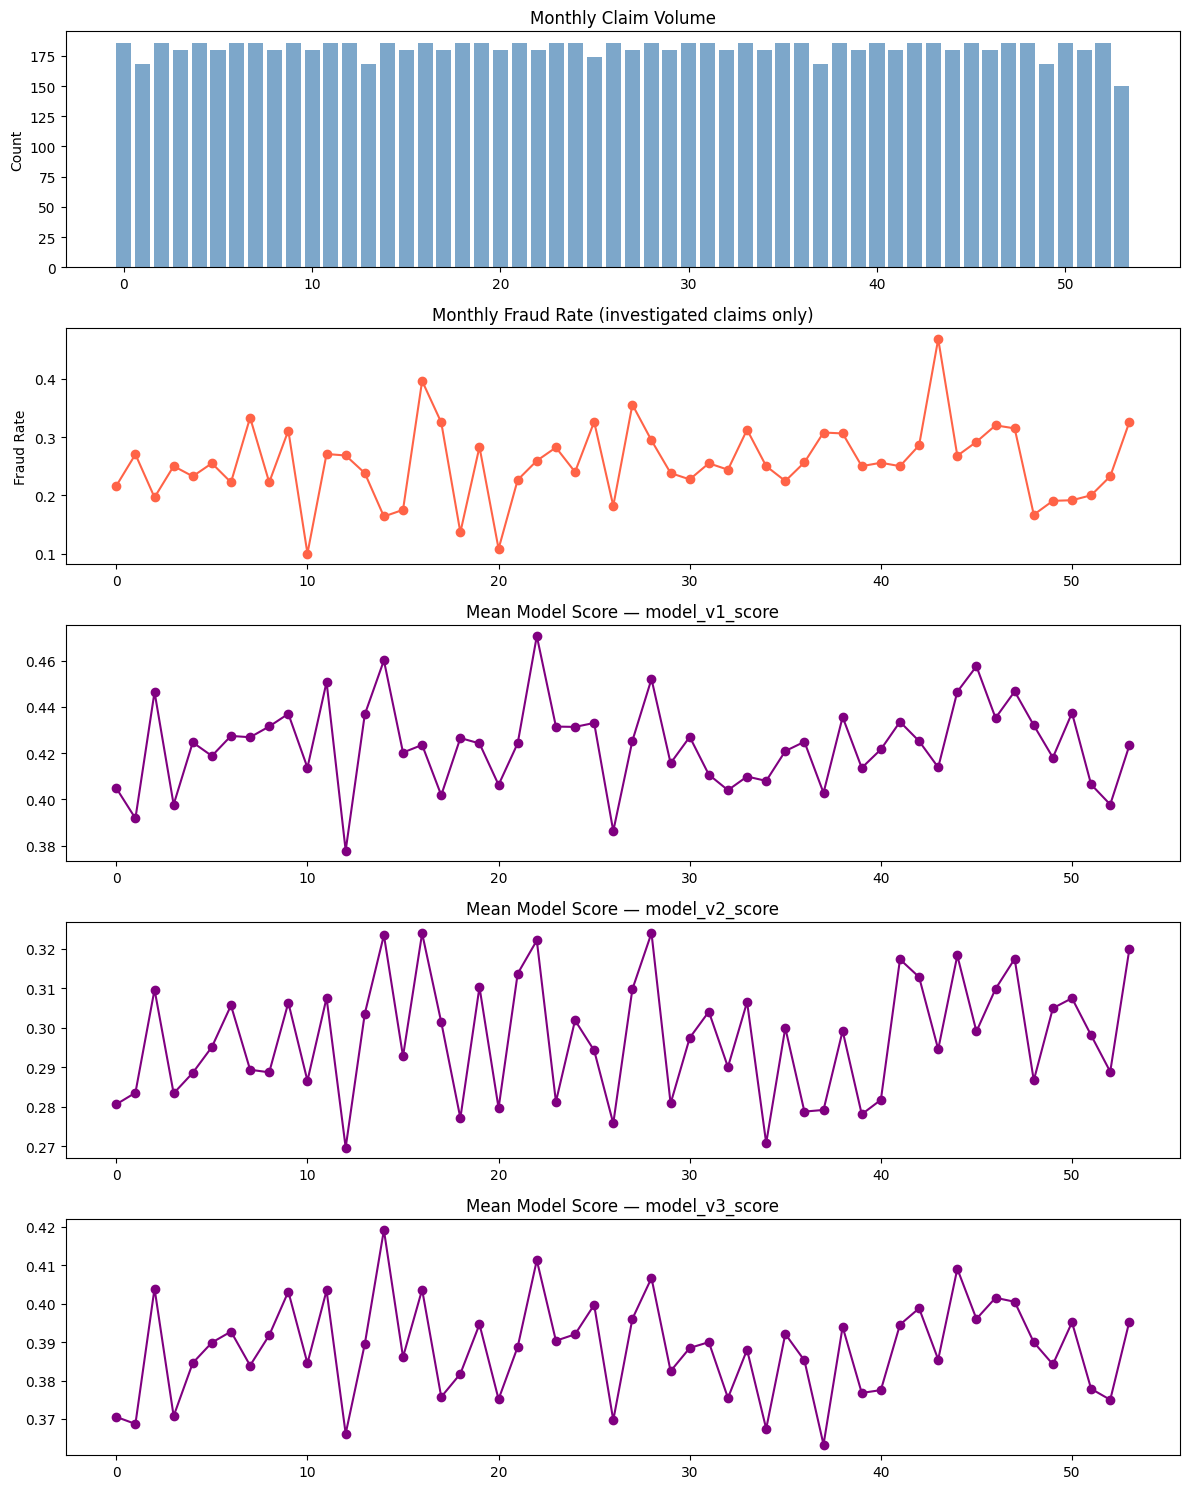

Saved: temporal_trends.png


In [32]:
analyse_temporal_trends(df_mapped)

## 🎯 What to look for in the printed output

**EN:**
- **Profile**: `fraud_label` should show ~75% missing (only investigated claims have labels) — this is the selective-labels signal
- **Fraud rates**: rising fraud rate across v1 → v2 → v3 in investigated claims, AND increasing concentration in the top score quartile → loop is active
- **Coverage**: correlation between score decile and investigation rate ≥ 0.8 → score-driven policy → MNAR labels
- **Temporal**: monthly mean score drifting upward across the date range → model becoming more confident on a narrowing population

**KR:**
- **Profile**: `fraud_label`이 약 75% 결측(조사된 클레임만 라벨 보유) → selective labels 신호
- **Fraud rates**: v1 → v2 → v3로 가면서 조사된 클레임의 fraud rate 상승 + 상위 quartile 집중도 증가 → 루프 작동 중
- **Coverage**: 점수 decile과 조사율 상관 ≥ 0.8 → 점수 기반 정책 → MNAR 라벨
- **Temporal**: 월별 평균 점수가 시간이 갈수록 상승 → 좁아지는 모집단에 모델 확신 증가

이 네 가지가 모두 보이면 **이 데이터셋(합성이지만)에 SFP 루프가 명확히 박혀 있는 것**입니다. 실 Allianz 데이터에서도 동일한 패턴을 찾아내는 게 Build 02 (loop detector)의 역할.